# IKT526 Final Project - Part 2: Instruction Fine-Tuning
This notebook contains my full implementation of the instruction-tuning task described in Part 2 of the assignment. The workflow follows the specification closely: the Alpaca dataset is loaded and split reproducibly (5:1:1), the text is formatted for instruction fine-tuning, and the Llama-3.2-1B model is trained using LoRA so that only the adapter weights are updated.

The training loop is implemented manually in PyTorch. I run validation before training starts and again after every epoch, and I log training/validation loss, training time, and peak GPU memory usage. The model checkpoint with the lowest validation loss is saved automatically.

For evaluation, I compare the base model and the fine-tuned model on ten examples taken from the held-out test set. To make sure these examples are genuinely diverse, I use a semantic embedding-based classifier instead of simple keyword matching. This classifier is built with a local SentenceTransformer model and prototype embeddings learned directly from the Alpaca dataset. By embedding all instructions, finding representative neighbors for each category, and categorizing new instructions using cosine similarity, the system captures the actual semantic patterns in the data. This leads to much better coverage of different instruction types, so the ten selected test examples reflect a broad range of tasks whenever possible.

Finally, I run a sampling-strategy comparison on ten out-of-distribution prompts using greedy decoding, temperature sampling, and nucleus sampling. These results are saved as a second JSON file.

This notebook produces everything required for the written report w.r.t training behaviour, model configuration, LoRA rank details, evaluation metrics, sampling outputs, and figures for analysis.

In [1]:
import os
import random
from dataclasses import dataclass, asdict
from typing import Tuple, Optional, Any, Dict, List, Counter
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib as mpl
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from sentence_transformers import SentenceTransformer
from huggingface_hub import login
import load_dotenv
import os
from pathlib import Path
import time
import contextlib
import math
import json
import warnings
warnings.filterwarnings("ignore")

/home/coder/emerging/final_project/ikt526/final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# authenticate with HF
load_dotenv.load_dotenv(".env")
API_TOKEN = os.getenv("TOKEN")
login(token = API_TOKEN)

In [ ]:
# plot style from IKT215
def set_mpl_params(dpi: int = 200, figsize: Tuple[int, int] = (9, 6), grid: bool = True, font_size: int = 12, font_family: str = 'serif') -> None:
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family

In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
@dataclass
class Config:
    hf_model: str = "meta-llama/Llama-3.2-1B"
    dataset: str = "yahma/alpaca-cleaned"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    # 5/1/1 split
    train_size: int = 10000
    val_size: int = 2000
    test_size: int = 2000
    # training hyperparameters
    batch_size: int = 8
    grad_accum_steps: int = 2
    epochs: int = 3
    lr: float = 0.0002
    weight_decay: float = 0.01
    use_bf16: bool = True
    seed: int = 42
    # LoRA config
    lora_rank: int = 8
    lora_alpha: int = lora_rank * 2
    lora_dropout: float = 0.05
    # paths from assignment text
    output_dir: Path = Path("outputs/checkpoints")
    generations_dir: Path = Path("outputs/generations")
    plots_dir: Path = Path("outputs/plots")
    max_length: int = 512
    max_new_tokens: int = 200
    report_to: Optional[str] = "none"
    eval_examples: int = 10
    sampling_examples: int = 10

In [6]:
cfg = Config()
seed_everything(cfg.seed)
set_mpl_params()
cfg.output_dir.mkdir(parents = True, exist_ok = True)
cfg.generations_dir.mkdir(parents = True, exist_ok = True)
cfg.plots_dir.mkdir(parents = True, exist_ok = True)
cfg

Config(hf_model='meta-llama/Llama-3.2-1B', dataset='yahma/alpaca-cleaned', device='cuda', train_size=10000, val_size=2000, test_size=2000, batch_size=8, grad_accum_steps=2, epochs=3, lr=0.0002, weight_decay=0.01, use_bf16=True, seed=42, lora_rank=8, lora_alpha=16, lora_dropout=0.05, output_dir=PosixPath('outputs/checkpoints'), generations_dir=PosixPath('outputs/generations'), plots_dir=PosixPath('outputs/plots'), max_length=512, max_new_tokens=200, report_to='none', eval_examples=10, sampling_examples=10)

In [7]:
s_dataset = load_dataset(cfg.dataset)
s_train = s_dataset["train"].shuffle(seed = cfg.seed)
train_dataset = s_train.select(range(cfg.train_size))
val_dataset = s_train.select(range(cfg.train_size, cfg.train_size + cfg.val_size))
test_dataset = s_train.select(range(cfg.train_size + cfg.val_size, cfg.train_size + cfg.val_size + cfg.test_size))
print(f"{len(train_dataset)}")
print(f"{len(val_dataset)}")
print(f"{len(test_dataset)}")

10000
2000
2000


In [8]:
dataset = DatasetDict({"train": train_dataset, "validation": val_dataset, "test": test_dataset})
dataset

DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 2000
    })
})

In [9]:
# format Alpaca entries into a single text field
# - "prompt" (instruction + optional input + 'Answer:')
# - "response" (output)
# - "text" = prompt + response (used for teacher-forced LM)
def formatting(example: Dict[str, Any]) -> Dict[str, Any]:
    instruction: str = example["instruction"]
    input: str = example["input"]
    output: str = example["output"]
    if input:
        prompt = f"Instruction: {instruction}\nInput: {input}\nAnswer:"
    else:
        prompt = f"Instruction: {instruction}\nAnswer:"
    text = prompt + " " + output
    return {"prompt": prompt, "response": output, "text": text, "instruction": instruction, "input": input, "output": output}

In [10]:
dataset = dataset.map(formatting)
dataset

DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction', 'prompt', 'response', 'text'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction', 'prompt', 'response', 'text'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['output', 'input', 'instruction', 'prompt', 'response', 'text'],
        num_rows: 2000
    })
})

In [11]:
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
# seed phrases for each category, used only to retrieve nearest real Alpaca instructions
SEED_PHRASES = {
    "list_gen": ["list several items", "generate multiple examples"],
    "creative": ["write a story", "creative writing prompt"],
    "explanation": ["explain a concept", "describe something"],
    "classification": ["categorize items", "compare differences"],
    "math": ["solve a math problem", "calculate a result"],
    "other": ["general instruction", "misc task"]
}

# embed entire dataset instructions
instructions = [ex["instruction"] for ex in dataset["train"]]
emb_dataset = embed_model.encode(instructions, batch_size = 64, show_progress_bar = True)
# top NN prototypes for each category
def nearest_neighbors(seed_vecs, all_vecs, top_k = 10):
    sims = np.dot(seed_vecs, all_vecs.T)
    idxs = np.argsort(-sims, axis=1)[:, :top_k]
    return np.unique(idxs.flatten())

PROTOTYPES = {}
for cat, seeds in SEED_PHRASES.items():
    seed_vecs = embed_model.encode(seeds)
    idxs = nearest_neighbors(seed_vecs, emb_dataset, top_k = 10)
    PROTOTYPES[cat] = emb_dataset[idxs]   # store prototype embeddings
    
# categorizer function
def categorize_instruction(instruction: str):
    v = embed_model.encode(instruction)
    v_norm = np.linalg.norm(v)
    best_cat = None
    best_score = -1
    for cat, proto_vecs in PROTOTYPES.items():
        norms = np.linalg.norm(proto_vecs, axis = 1)
        sims = (proto_vecs @ v) / (norms * v_norm)
        score = sims.max()  # best similarity to this category
        if score > best_score:
            best_score = score
            best_cat = cat
    return best_cat, float(best_score)

Batches: 100%|██████████| 157/157 [00:01<00:00, 87.98it/s] 


In [12]:
# wrapper for the categorizer function
def categorize_instruction_label_only(instr: str) -> str:
    cat, _ = categorize_instruction(instr)
    return cat

In [13]:
tokenizer = AutoTokenizer.from_pretrained(cfg.hf_model, use_fast = True)
# set pad_token to eos_token for decoder-only LM
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
def tokenize(batch) -> dict:
    return tokenizer(batch["text"], truncation = True, max_length = cfg.max_length, padding = "max_length")

In [14]:
tokenized = dataset.map(tokenize, batched = True, remove_columns = dataset["train"].column_names)
tokenized.set_format(type = "torch")
tokenized

Map: 100%|██████████| 2000/2000 [00:00<00:00, 3307.03 examples/s]


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [15]:
# PyTorch DataLoaders, default collate_fn (stacks dict of tensors)
train_loader = DataLoader(tokenized["train"], batch_size = cfg.batch_size, shuffle = True)
val_loader = DataLoader(tokenized["validation"], batch_size = cfg.batch_size, shuffle = False)

In [16]:
dtype = torch.bfloat16 if (cfg.use_bf16 and cfg.device == "cuda") else torch.float32
model = AutoModelForCausalLM.from_pretrained(cfg.hf_model, torch_dtype = dtype, device_map = "auto")
model = prepare_model_for_kbit_training(model)
lora_cfg = LoraConfig(r = cfg.lora_rank, lora_alpha = cfg.lora_alpha, lora_dropout = cfg.lora_dropout, target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"], task_type = "CAUSAL_LM")
model = get_peft_model(model, lora_cfg)
# sanity check that only LoRA params are trainable
model.print_trainable_parameters()

trainable params: 1,703,936 || all params: 1,237,518,336 || trainable%: 0.1377


In [ ]:
# evaluation function, average loss over validation set
actx = (torch.autocast(device_type = "cuda", dtype = torch.bfloat16)
        if (cfg.use_bf16 and cfg.device == "cuda")
        else contextlib.nullcontext())

def evaluate_loss(model: torch.nn.Module, dataloader: DataLoader, cfg: Config) -> float:
    model.eval()
    total_loss = 0.0
    total_examples = 0
    with torch.no_grad(), actx:
        for batch in dataloader:
            batch = {k: v.to(cfg.device) for k, v in batch.items()}
            labels = batch["input_ids"].clone()
            outputs = model(input_ids = batch["input_ids"], attention_mask = batch["attention_mask"], labels = labels)
            loss = outputs.loss
            bs = batch["input_ids"].size(0)
            total_loss += loss.item() * bs
            total_examples += bs

    if total_examples == 0:
        return float("inf")
    return total_loss / total_examples

In [18]:
def plot_curves(log_history: List[Dict[str, Any]], cfg: Config) -> None:
    save_path = cfg.plots_dir / "loss_curves.png"
    train_steps: List[int] = []
    train_losses: List[float] = []
    eval_steps: List[int] = []
    eval_losses: List[float] = []
    for log in log_history:
        if "loss" in log and "step" in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])
        if "eval_loss" in log and "step" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])

    plt.figure()
    if train_steps:
        plt.plot(train_steps, train_losses, label = "Train loss")
    if eval_steps:
        plt.plot(eval_steps, eval_losses, label = "Validation loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi = 250)
    plt.show()

In [19]:
optimizer = torch.optim.AdamW(model.parameters(), lr = cfg.lr, weight_decay = cfg.weight_decay)
log_history: List[Dict[str, Any]] = []
global_step = 0
best_val_loss = float("inf")
best_epoch = -1
if cfg.device == "cuda":
    torch.cuda.reset_peak_memory_stats()
start_time = time.time()
# initial validation at epoch 0, step 0
initial_val_loss = evaluate_loss(model, val_loader, cfg)
best_val_loss = initial_val_loss
best_epoch = 0
best_model_path = cfg.output_dir / "best_model.pt"
torch.save(
    {
        "epoch": 0,
        "val_loss": initial_val_loss,
        "adapter_state_dict": model.state_dict(),
        "config": {
            "lora_rank": cfg.lora_rank,
            "lora_alpha": cfg.lora_alpha,
            "lora_dropout": cfg.lora_dropout,
            "base_model": cfg.hf_model
        },
    },
    best_model_path)
log_history.append({"step": global_step, "epoch": 0, "eval_loss": initial_val_loss})
print(f"{initial_val_loss:.4f}")
# training loop
for epoch in range(1, cfg.epochs + 1):
    model.train()
    running_loss = 0.0
    running_batches = 0
    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        labels = batch["input_ids"].clone()
        with actx:
            outputs = model(input_ids = batch["input_ids"], attention_mask = batch["attention_mask"], labels = labels)
            loss = outputs.loss
            # gradient accumulation
            loss = loss / cfg.grad_accum_steps
        loss.backward()
        running_loss += loss.item()
        running_batches += 1
        # perform optimizer step every grad_accum_steps
        if ((batch_idx + 1) % cfg.grad_accum_steps == 0 or (batch_idx + 1) == len(train_loader)):
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1
            avg_loss = running_loss / running_batches
            log_history.append({"step": global_step, "epoch": epoch, "loss": avg_loss})
            running_loss = 0.0
            running_batches = 0

    # validation at the end of each epoch
    val_loss = evaluate_loss(model, val_loader, cfg)
    log_history.append({"step": global_step, "epoch": epoch, "eval_loss": val_loss})
    # save best adapter weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save({
                "epoch": epoch,
                "val_loss": val_loss,
                "adapter_state_dict": model.state_dict(),
                "config": {
                    "lora_rank": cfg.lora_rank,
                    "lora_alpha": cfg.lora_alpha,
                    "lora_dropout": cfg.lora_dropout,
                    "base_model": cfg.hf_model
                },
            },
            best_model_path)
    print(f"Epoch {epoch}/{cfg.epochs}, validation loss {val_loss:.4f}, best so far is {best_val_loss:.4f})") 

end_time = time.time()
train_time_sec: float = end_time - start_time
train_time_min: float = train_time_sec / 60.0
gpu_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
train_stats = {"train_time_sec": train_time_sec, "train_time_min": train_time_min, "gpu_memory_gb": gpu_memory_gb, "best_epoch": best_epoch, "best_val_loss": best_val_loss}
print(f"training took {train_time_min:.2f} minutes")
print(f"peak GPU memory is {gpu_memory_gb:.2f} GB" if gpu_memory_gb is not None else "GPU not used")
train_stats

7.1702
Epoch 1/3, validation loss 0.4506, best so far is 0.4506)
Epoch 2/3, validation loss 0.4424, best so far is 0.4424)
Epoch 3/3, validation loss 0.4250, best so far is 0.4250)
training took 162.09 minutes
peak GPU memory is 26.24 GB


{'train_time_sec': 9725.299490213394,
 'train_time_min': 162.0883248368899,
 'gpu_memory_gb': 26.241172313690186,
 'best_epoch': 3,
 'best_val_loss': 0.42499659329652784}

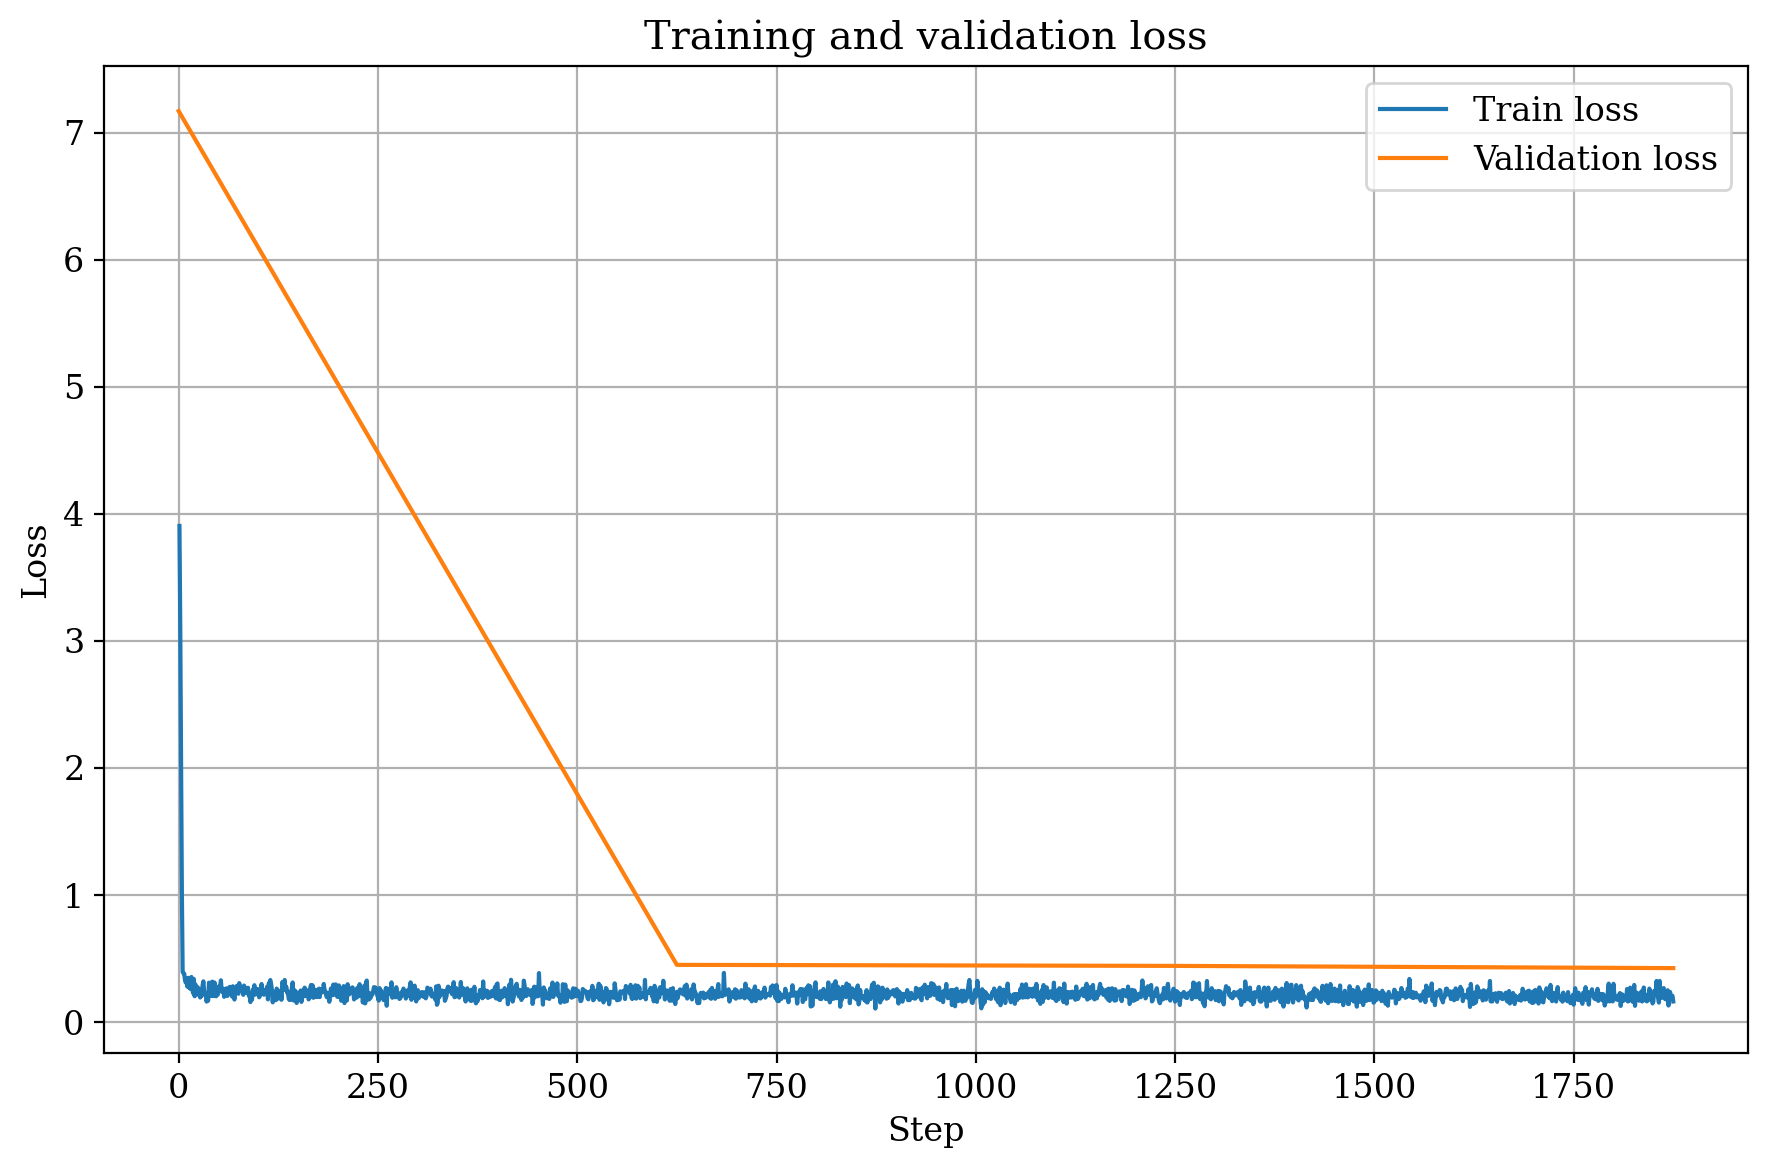

In [20]:
plot_curves(log_history, cfg)

In [67]:
# reload best LoRA adapter from best_model.pt into a fresh base model
checkpoint = torch.load(best_model_path, map_location = "cpu")
best_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["val_loss"]
base_model_eval = AutoModelForCausalLM.from_pretrained(cfg.hf_model, torch_dtype = dtype)
base_model_eval.to(cfg.device)
model = get_peft_model(base_model_eval, lora_cfg)
model.load_state_dict(checkpoint["adapter_state_dict"])
model.to(cfg.device)
print(f"loaded best adapter from epoch {best_epoch} with val_loss {best_val_loss:.4f}")

loaded best adapter from epoch 3 with val_loss 0.4250


In [68]:
def generate_answer(model: torch.nn.Module, prompt: str, max_new_tokens: Optional[int] = None, **gen_kwargs: Any) -> str:
    if max_new_tokens is None:
        max_new_tokens = cfg.max_new_tokens
    model.eval()
    inputs = tokenizer(prompt, return_tensors = "pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens = max_new_tokens, pad_token_id = tokenizer.eos_token_id, **gen_kwargs)
    # decode the entire generated sequence
    full_text = tokenizer.decode(output_ids[0], skip_special_tokens = True)
    if full_text.startswith(prompt):
        answer = full_text[len(prompt):].strip()
    else:
        answer = full_text.strip()
    return answer

In [69]:
def log_likelihood(model: torch.nn.Module, text: str) -> Tuple[float, int]:
    model.eval()
    enc = tokenizer(text, return_tensors = "pt", truncation = True, max_length = cfg.max_length).to(model.device)
    input_ids = enc["input_ids"]
    with torch.no_grad():
        outputs = model(input_ids=input_ids)
        logits = outputs.logits  # [B, T, V]
    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]
    log_probs = torch.log_softmax(shift_logits, dim = -1)
    token_log_probs = log_probs.gather(-1, shift_labels.unsqueeze(-1)).squeeze(-1)
    mask = shift_labels != tokenizer.pad_token_id
    token_log_probs = token_log_probs[mask]
    total_logprob = token_log_probs.sum().item()
    token_count = int(mask.sum().item())
    return total_logprob, token_count

In [70]:
def perplexity(model: torch.nn.Module, text: str) -> float:
    total_logprob, token_count = log_likelihood(model, text)
    if token_count == 0:
        return float("inf")
    return math.exp(-total_logprob / token_count)

In [71]:
# token-level F1 (bag-of-tokens, order ignored)
def token_f1(pred: str, ref: str) -> float:
    pred_tokens = pred.split()
    ref_tokens = ref.split()
    if not pred_tokens or not ref_tokens:
        return 0.0
    pred_counter = Counter(pred_tokens)
    ref_counter = Counter(ref_tokens)
    common = sum((pred_counter & ref_counter).values())
    if common == 0:
        return 0.0
    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

In [72]:
# base model for comparison
base_eval_model = AutoModelForCausalLM.from_pretrained(cfg.hf_model, torch_dtype = dtype)
base_eval_model.to(cfg.device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm):

In [73]:
# selecting 10 eval examples from the held out test set
def select_diverse_examples(ds, k = cfg.eval_examples, seed = cfg.seed):
    rng = random.Random(seed)
    indices = list(range(len(ds)))
    rng.shuffle(indices)
    selected = []
    categories_seen = set()
    # prioritize unique instruction categories
    for idx in indices:
        ex = ds[idx]
        cat = categorize_instruction_label_only(ex["instruction"])
        if cat not in categories_seen:
            selected.append(ex)
            categories_seen.add(cat)
            if len(selected) == k:
                return selected
    # fallback (if dataset is unbalanced)
    while len(selected) < k:
        selected.append(ds[rng.choice(indices)])
    return selected

eval_examples = select_diverse_examples(dataset["test"], k = cfg.eval_examples, seed = cfg.seed)
print([categorize_instruction_label_only(ex["instruction"]) for ex in eval_examples])
print(len(eval_examples))

['math', 'list_gen', 'creative', 'explanation', 'other', 'classification', 'creative', 'explanation', 'explanation', 'explanation']
10


In [74]:
def build_prompt(instruction: str, inp: str = "") -> str:
    if inp:
        return f"Instruction: {instruction}\nInput: {inp}\nAnswer:"
    else:
        return f"Instruction: {instruction}\nAnswer:"

In [75]:
results: List[Dict[str, Any]] = []
base_ppls: List[float] = []
base_f1s: List[float] = []
ft_ppls: List[float] = []
ft_f1s: List[float] = []
for i, ex in enumerate(eval_examples):
    example_id = i
    instruction = ex["instruction"]
    inp = ex["input"]
    reference = ex["output"]
    prompt = build_prompt(instruction, inp)
    # base model generation (greedy)
    base_answer = generate_answer(base_eval_model, prompt, do_sample = False)
    # LoRA fine-tuned model generation (greedy)
    ft_answer = generate_answer(model, prompt, do_sample = False)
    # metrics (PPL on generated output only)
    base_ppl = perplexity(base_eval_model, base_answer)
    ft_ppl = perplexity(model, ft_answer)
    base_f1_val = token_f1(base_answer, reference)
    ft_f1_val = token_f1(ft_answer, reference)
    base_ppls.append(base_ppl)
    base_f1s.append(base_f1_val)
    ft_ppls.append(ft_ppl)
    ft_f1s.append(ft_f1_val)
    results.append(
        {
            "example_id": example_id,
            "instruction": instruction,
            "input": inp,
            "reference_output": reference,
            "base_output": base_answer,
            "finetuned_output": ft_answer,
            "base_metrics": {
                "perplexity": base_ppl,
                "f1": base_f1_val,
                "qualitative_score": None
            },
            "finetuned_metrics": {
                "perplexity": ft_ppl,
                "f1": ft_f1_val,
                "qualitative_score": None
            },
        }
    )

In [76]:
def serialize_config(cfg_dict: Dict[str, Any]) -> Dict[str, Any]:
    out: Dict[str, Any] = {}
    for k, v in cfg_dict.items():
        if isinstance(v, Path):
            out[k] = str(v)
        else:
            out[k] = v
    return out

summary = {
    "base": {
        "ppl_mean": float(np.mean(base_ppls)),
        "ppl_std": float(np.std(base_ppls)),
        "f1_mean": float(np.mean(base_f1s)),
        "f1_std": float(np.std(base_f1s))
    },
    "finetuned": {
        "ppl_mean": float(np.mean(ft_ppls)),
        "ppl_std": float(np.std(ft_ppls)),
        "f1_mean": float(np.mean(ft_f1s)),
        "f1_std": float(np.std(ft_f1s))
    },
}

eval_report = {"config": serialize_config(asdict(cfg)), "train_stats": train_stats, "summary": summary, "examples": results}
in_dist_path = cfg.generations_dir / "in_distribution_eval.json"
with open(in_dist_path, "w") as f:
    json.dump(eval_report, f, indent = 4)

In [77]:
summary

{'base': {'ppl_mean': 3.3512308466451244,
  'ppl_std': 4.168436198451136,
  'f1_mean': 0.17618393012223846,
  'f1_std': 0.13316391130307567},
 'finetuned': {'ppl_mean': 15.040589736776562,
  'ppl_std': 21.71396875008369,
  'f1_mean': 0.26163934746630196,
  'f1_std': 0.16624079836643582}}

In [78]:
# sampling strats
def greedy_sampling(prompt: str) -> str:
    return generate_answer(model, prompt, do_sample = False)

def temperature_sampling(prompt: str, temperature: float = 0.7) -> str:
    return generate_answer(model, prompt, do_sample = True, temperature = temperature, top_p = None)

def nucleus_sampling(prompt: str, top_p: float = 0.9) -> str:
    return generate_answer(model, prompt, do_sample = True, top_p = top_p, temperature = 1.0)

In [79]:
# out of distribution prompts source: exam questions from courses EX-109, MA-447, MA-223, IKT204. hypothetical creative questions based on IKT465. ML questions based on IKT526.
prompts: List[str] = [
    "Explain briefly what happens in an encounter between human beings according to the philosophies of Martin Buber, Simone de Beauvoir, and Jean-Paul Sartre.",
    "Under what conditions does empirical risk converge toward true risk in machine learning? Provide a clear explanation",
    "Describe the difference between optimization of linear and non-linear functions, including how constraints affect where their optimal solutions occur.",
    "IPv6 packets can be encapsulated inside IPv4 tunnels. Does this imply that IPv6 treats IPv4 as a link-layer protocol? Explain whether you agree or disagree and why.",
    "A disease affects 1 percent of the population. A diagnostic test has a 99 percent true positive rate and a 5 percent false positive rate. If a person tests positive once, what is the probability that they actually have the disease? Explain your reasoning.",
    "A company claims that its sugar packets weigh 1 kg on average. The population standard deviation is known to be 0.05 kg. A sample of 40 packets has an average weight of 0.98 kg. At a 5 percent significance level, test whether the company’s claim should be rejected.",
    "Explain the main difference between parameter-efficient fine-tuning methods such as LoRA and fully fine-tuning all model parameters. Include when and why LoRA is preferable.",
    "Explain why overfitting occurs during model training and describe two reliable ways to detect or prevent it.",
    "Imagine a future university where all research projects must use both Mode 1 and Mode 2 knowledge production. Describe a scenario where a group of students plans a research study under this rule. Explain their research question, their method, their data collection plan, and the steps they take to follow research integrity.",
    "Write a story about a researcher who must choose between publishing fast without full verification or following the scientific method with care. Show how concerns about academic integrity, plagiarism, and responsible research affect the choice.",
]
len(prompts)

10

In [80]:
sampling_results: List[Dict[str, Any]] = []
for i, prompt in enumerate(prompts):
    ood_prompt = build_prompt(instruction = prompt, inp = "")
    greedy_out = greedy_sampling(ood_prompt)
    temp_out = temperature_sampling(ood_prompt, temperature = 0.7)
    nucleus_out = nucleus_sampling(ood_prompt, top_p = 0.9)
    sampling_results.append({"example_id": i, "prompt": prompt, "greedy_output": greedy_out, "temperature_0.7_output": temp_out, "top_p_0.9_output": nucleus_out})
sampling_report = {"config": serialize_config(asdict(cfg)), "model": "Llama-3.2-1B-LoRA", "examples": sampling_results}
ood_path = cfg.generations_dir / "out_of_distribution_sampling.json"
with open(ood_path, "w") as f:
    json.dump(sampling_report, f, indent = 4)
len(sampling_results)

10

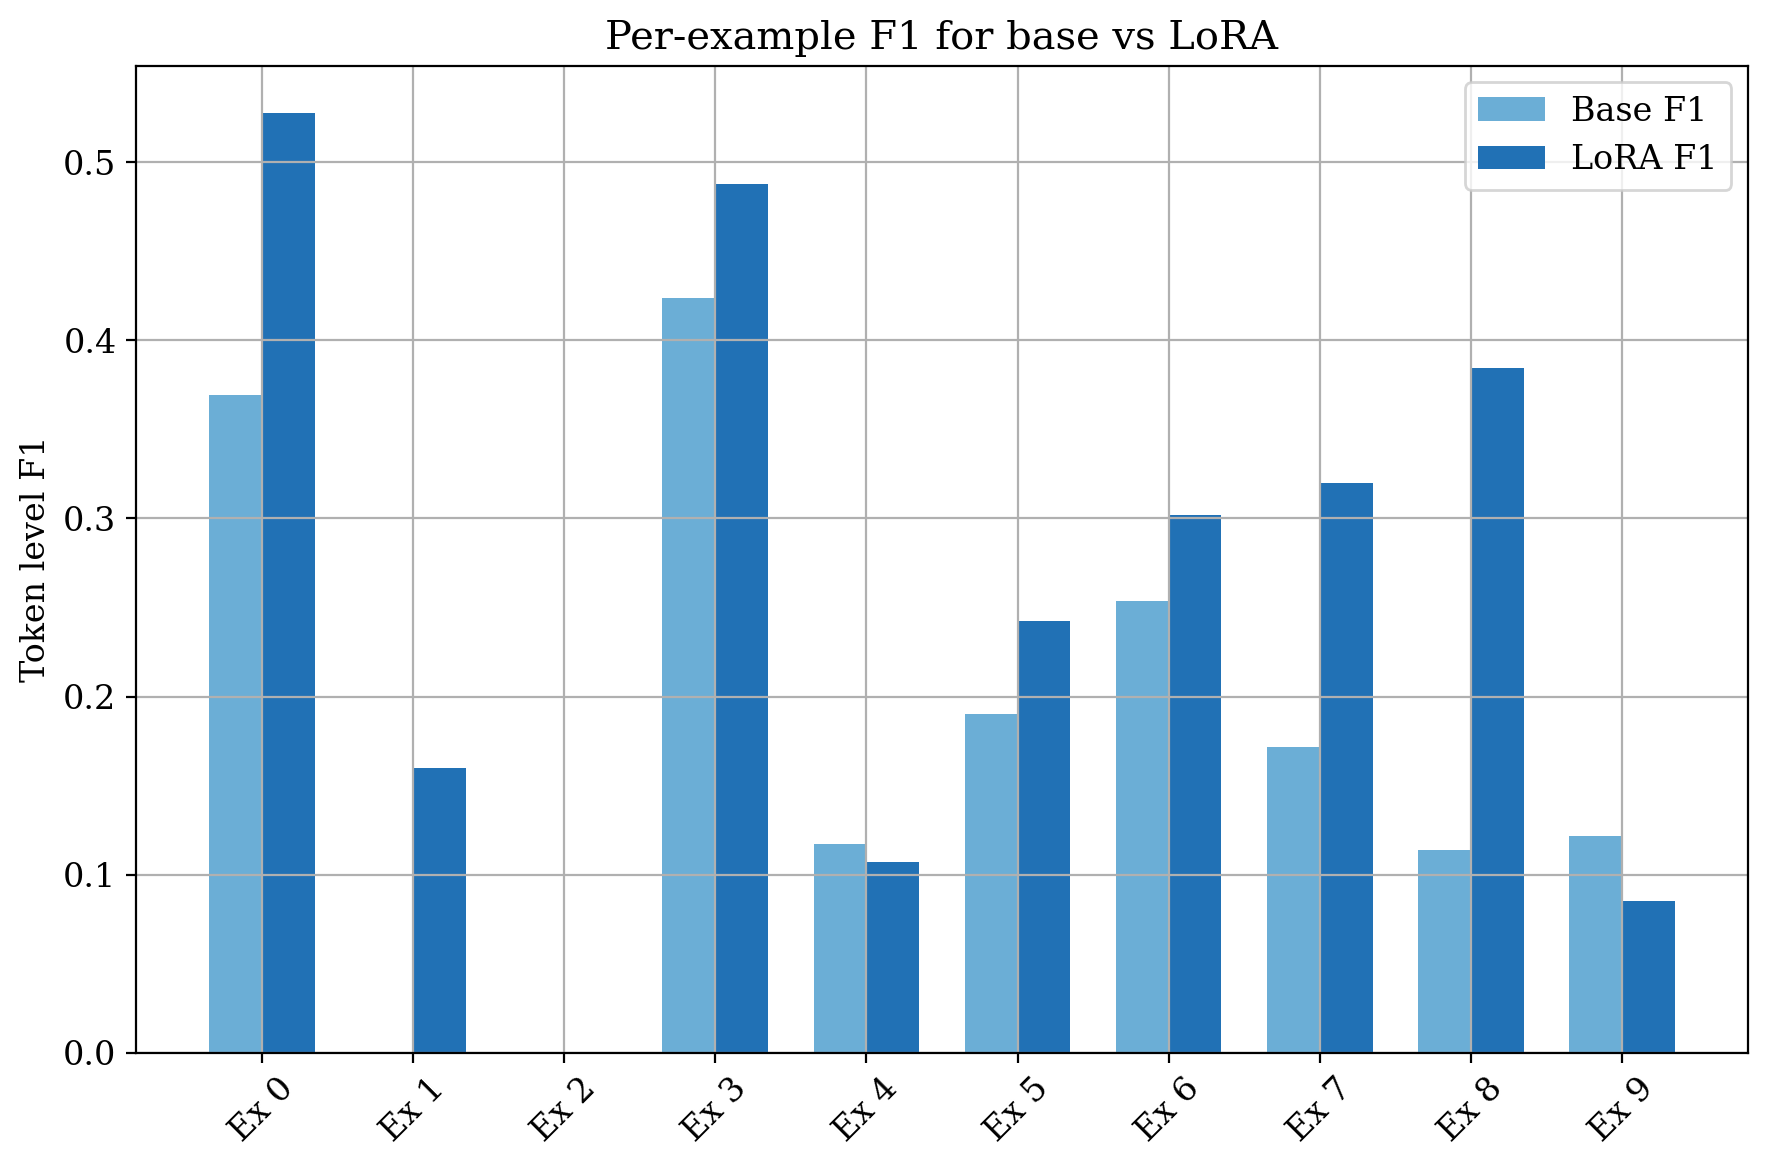

In [81]:
# per-example F1 and PPL comparison plots
labels = [f"Ex {i}" for i in range(cfg.eval_examples)]
x = np.arange(len(labels))
width = 0.35
base_color = "#6baed6"  # light blue
lora_color = "#2171b5"  # darker blue
plt.figure()
plt.bar(x - width / 2, base_f1s, width, label = "Base F1", color = base_color)
plt.bar(x + width / 2, ft_f1s, width, label = "LoRA F1", color = lora_color)
plt.xticks(x, labels, rotation = 45)
plt.ylabel("Token level F1")
plt.title("Per-example F1 for base vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(cfg.plots_dir / "per_example_f1.png", dpi = 250)
plt.show()

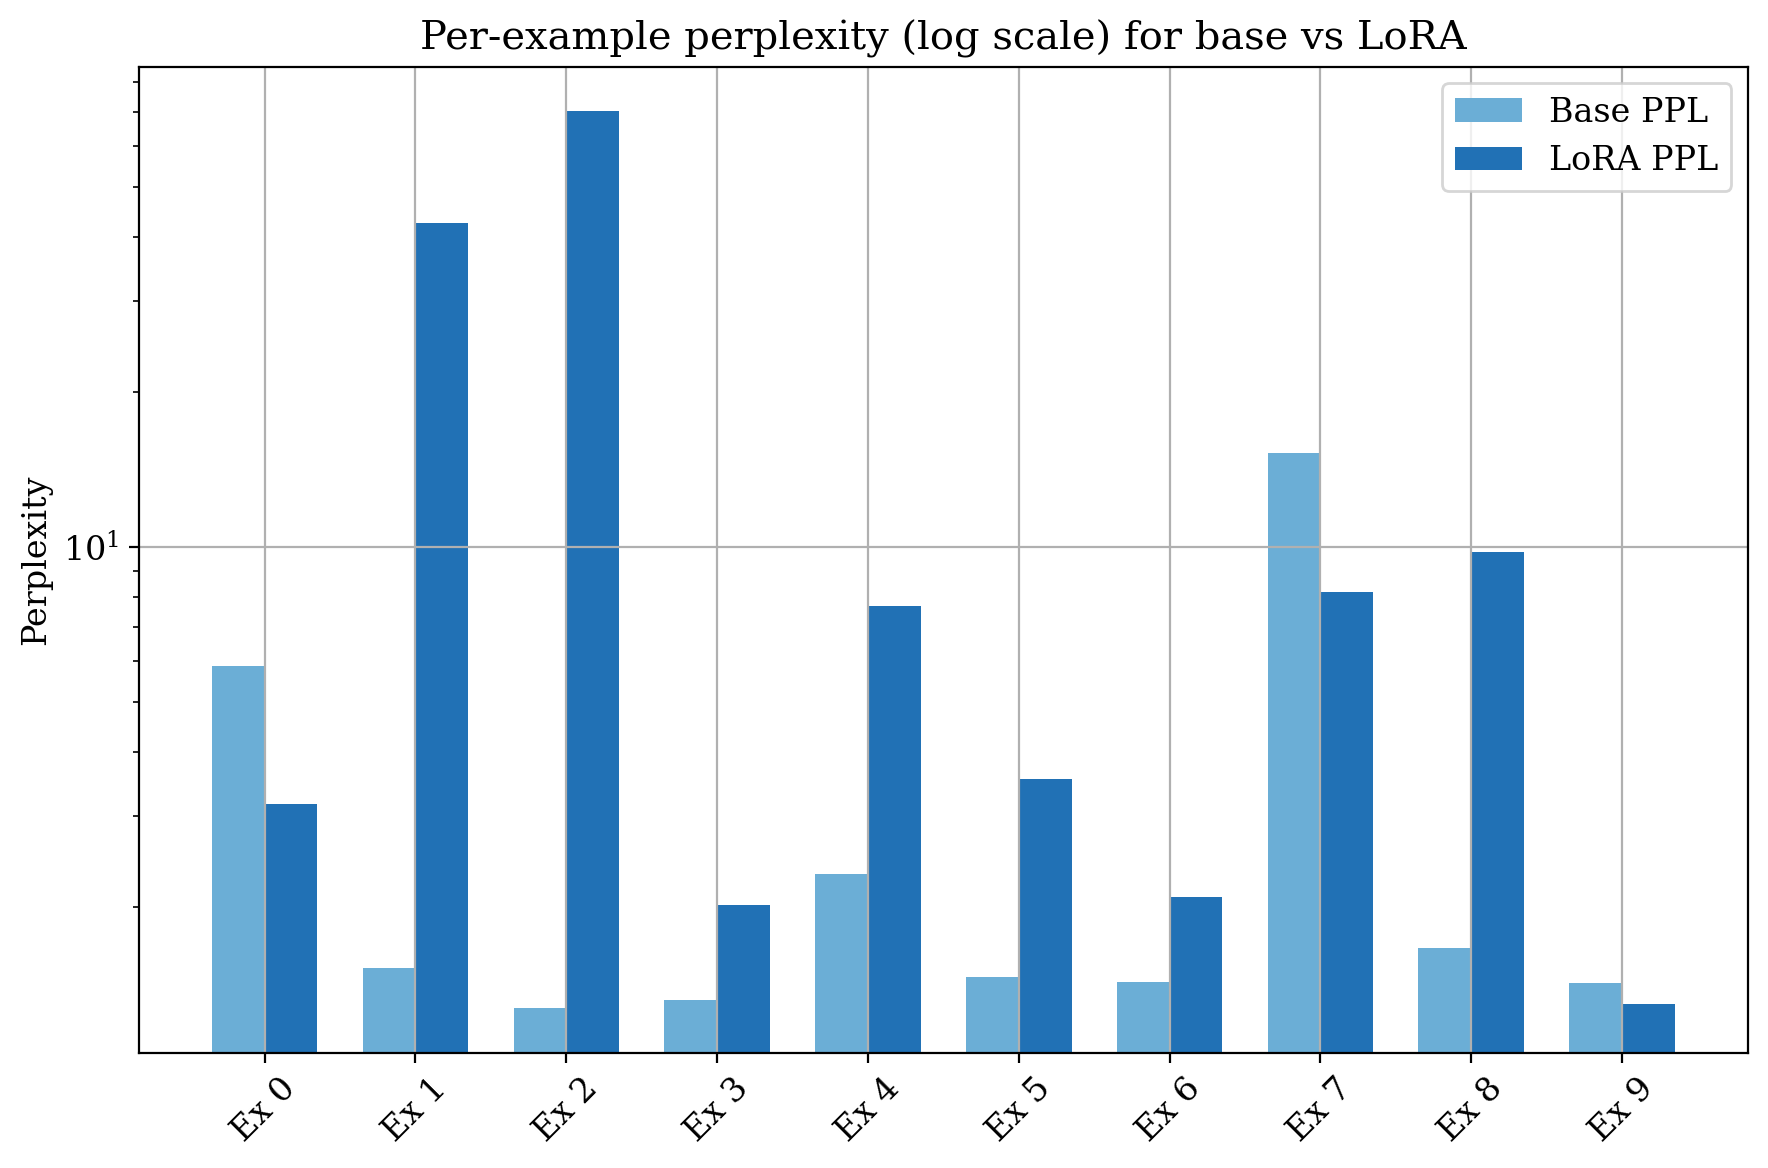

In [65]:
plt.figure()
plt.bar(x - width / 2, base_ppls, width, label = "Base PPL", color = base_color)
plt.bar(x + width / 2, ft_ppls, width, label = "LoRA PPL", color = lora_color)
plt.xticks(x, labels, rotation = 45)
plt.ylabel("Perplexity")
plt.yscale("log")
plt.title("Per-example perplexity (log scale) for base vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(cfg.plots_dir / "per_example_perplexity.png", dpi = 250)
plt.show()